In [1]:
import torch
torch.__version__

'2.6.0+cu126'

In [2]:
import pandas as od
import numpy as np
import matplotlib.pyplot as plt
from torch import nn

In [3]:
#Data Creation/ Loading
weight=0.7
bias=0.3
X=torch.arange(0,1,0.02).unsqueeze(dim=1)
y=bias + weight * X
print(len(X), len(y))
X[:7] , y[:7]

50 50


(tensor([[0.0000],
         [0.0200],
         [0.0400],
         [0.0600],
         [0.0800],
         [0.1000],
         [0.1200]]),
 tensor([[0.3000],
         [0.3140],
         [0.3280],
         [0.3420],
         [0.3560],
         [0.3700],
         [0.3840]]))

In [4]:
split=int(0.8*len(X))
x_train,y_train = X[:split],y[:split]
x_test,y_test = X[split:],y[split:]
x_test

tensor([[0.8000],
        [0.8200],
        [0.8400],
        [0.8600],
        [0.8800],
        [0.9000],
        [0.9200],
        [0.9400],
        [0.9600],
        [0.9800]])

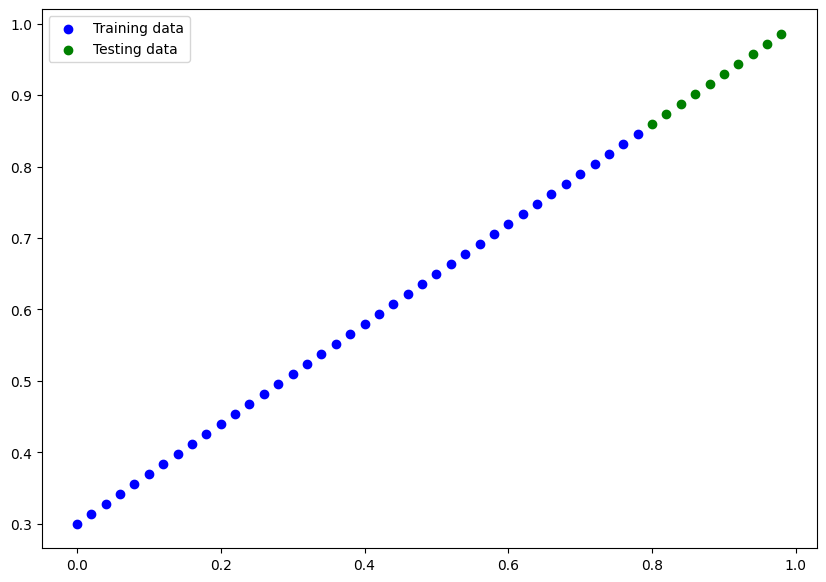

In [18]:
def plot_predictions(train_data=x_train,train_labels=y_train,test_data=x_test,test_labels=y_test,predictions=None):
    plt.figure(figsize=(10,7))
    plt.scatter(train_data,train_labels,c="b",label="Training data")
    plt.scatter(test_data,test_labels,c="g",label="Testing data")
    if predictions is not None:
        plt.scatter(test_data,predictions,c="r",label="Predictions")
    plt.legend(prop={"size":10})
plot_predictions()

In [32]:
#model
class LinearRegressionModel(nn.Module):
    def __init__(self):
        super().__init__()
        self.weights = nn.Parameter(torch.randn(1,requires_grad=True,dtype=torch.float))
        self.bias = nn.Parameter(torch.rand(1,requires_grad=True,dtype=torch.float))
    def forward(self, x:torch.Tensor) -> torch.Tensor:
        return self.weights * x + self.bias

In [33]:
torch.manual_seed(42)
model_0=LinearRegressionModel()
print(list(model_0.parameters()))
model_0.state_dict()

[Parameter containing:
tensor([0.3367], requires_grad=True), Parameter containing:
tensor([0.3904], requires_grad=True)]


OrderedDict([('weights', tensor([0.3367])), ('bias', tensor([0.3904]))])

tensor([[0.6598],
        [0.6665],
        [0.6733],
        [0.6800],
        [0.6867],
        [0.6935],
        [0.7002],
        [0.7069],
        [0.7137],
        [0.7204]])


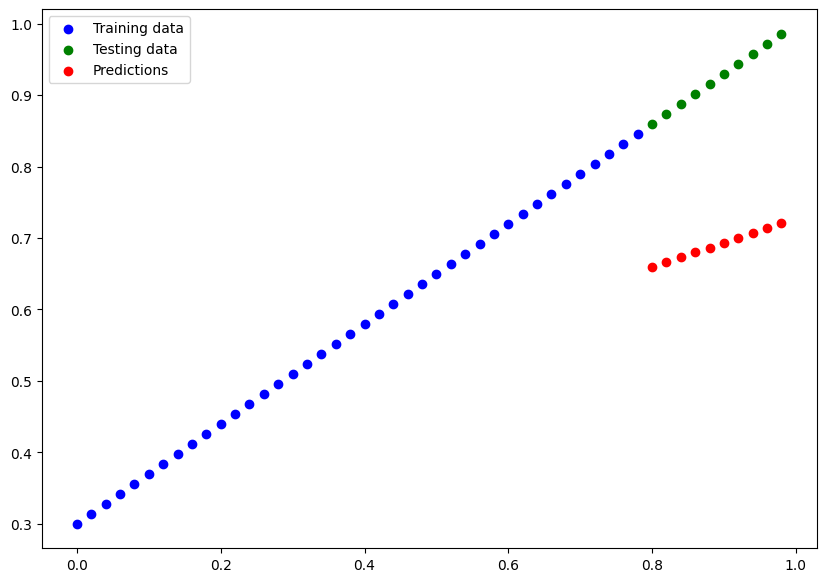

In [34]:
with torch.inference_mode():
    y_preds=model_0(x_test)

print(y_preds)
plot_predictions(predictions=y_preds)

In [35]:
loss_fn=nn.L1Loss()
optimizer=torch.optim.SGD(params=model_0.parameters(), lr=0.01)

In [38]:
epochs=100
train_loss_values=[]
test_loss_values=[]
epoch_count=[]

for epoch in range(epochs):
    model_0.train()
    y_pred=model_0(x_train)
    loss=loss_fn(y_pred,y_train)
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    model_0.eval()
    with torch.inference_mode():
        test_pred=model_0(x_test)
        test_loss=loss_fn(test_pred, y_test.type(torch.float))
        if epoch%10==0:
            epoch_count.append(epoch)
            train_loss_values.append(loss.detach().numpy())
            test_loss_values.append(test_loss.detach().numpy())
            print(f"Epoch: {epoch} | MAE train loss: {loss} | MAE test loss: {test_loss}")

Epoch: 0 | MAE train loss: 0.034646838903427124 | MAE test loss: 0.08051808178424835
Epoch: 10 | MAE train loss: 0.031217509880661964 | MAE test loss: 0.0722455382347107
Epoch: 20 | MAE train loss: 0.027778705582022667 | MAE test loss: 0.06397300213575363
Epoch: 30 | MAE train loss: 0.024344902485609055 | MAE test loss: 0.05638733506202698
Epoch: 40 | MAE train loss: 0.020913895219564438 | MAE test loss: 0.04811479523777962
Epoch: 50 | MAE train loss: 0.017475087195634842 | MAE test loss: 0.03984225541353226
Epoch: 60 | MAE train loss: 0.014042967930436134 | MAE test loss: 0.0322565920650959
Epoch: 70 | MAE train loss: 0.010610274039208889 | MAE test loss: 0.02398405596613884
Epoch: 80 | MAE train loss: 0.007171472068876028 | MAE test loss: 0.015711510553956032
Epoch: 90 | MAE train loss: 0.003741039428859949 | MAE test loss: 0.008125847205519676


C:\Users\GLENN\AppData\Local\Temp\ipykernel_14012\742315978.py:6: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


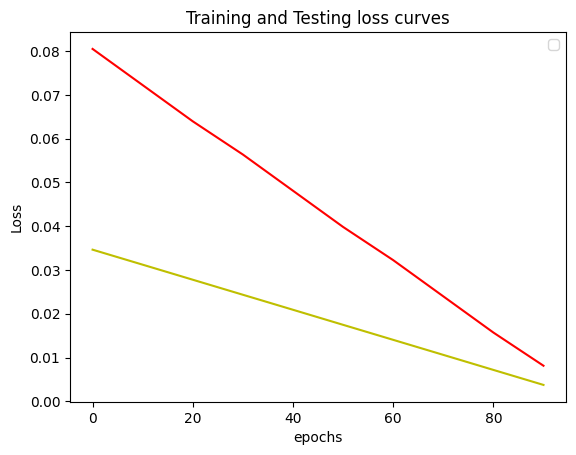

In [39]:
plt.plot(epoch_count, train_loss_values, c="y")
plt.plot(epoch_count, test_loss_values, c="r")
plt.title("Training and Testing loss curves")
plt.xlabel("epochs")
plt.ylabel("Loss")
plt.legend()

In [40]:
print(model_0.state_dict())
print(f"Actual weight: {weight} | Actual bias: {bias}")

OrderedDict({'weights': tensor([0.6962]), 'bias': tensor([0.3064])})
Actual weight: 0.7 | Actual bias: 0.3


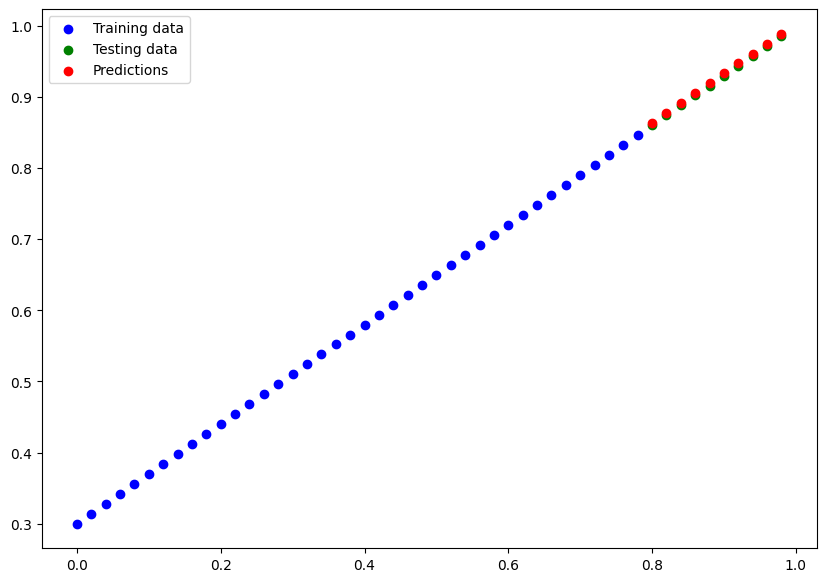

In [41]:
model_0.eval()
with torch.inference_mode():
    y_preds=model_0(x_test)
plot_predictions(predictions=y_preds)

In [43]:
from pathlib import Path

MODEL_PATH=Path("models")
MODEL_PATH.mkdir(parents=True, exist_ok=True)

MODEL_NAME="workflow_model_0.pth"
MODLE_SAVE_PATH=MODEL_PATH/MODEL_NAME

torch.save(obj=model_0.state_dict(), f=MODLE_SAVE_PATH)

In [44]:
model_1=LinearRegressionModel()
model_1.load_state_dict(torch.load(f=MODLE_SAVE_PATH))

<All keys matched successfully>

In [45]:
model_1.eval()
with torch.inference_mode():
    predicted=model_1(x_test)
predicted==y_preds    

tensor([[True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True],
        [True]])

In [ ]:
####################################

In [114]:
device="cuda" if torch.cuda.is_available() else "cpu"
device

'cuda'

In [115]:
X=torch.arange(1,30,1.3).unsqueeze(dim=1)
weights, biases= 0.85, 0.7
Y=weights*X+biases
X[:5], Y[:5], len(X)

(tensor([[1.0000],
         [2.3000],
         [3.6000],
         [4.9000],
         [6.2000]]),
 tensor([[1.5500],
         [2.6550],
         [3.7600],
         [4.8650],
         [5.9700]]),
 23)

In [116]:
X_train, X_test=X[:19].to(device),X[19:].to(device)
Y_train, Y_test=Y[:19].to(device),Y[19:].to(device)
X_train.device

device(type='cuda', index=0)

In [117]:
class LinearRegressionModel2(nn.Module):
    def __init__(self):
        super().__init__()
        self.linear_layer=nn.Linear(in_features=1, out_features=1)
    def forward(self, X:torch.Tensor) -> torch.Tensor:
        return self.linear_layer(X)
    
torch.manual_seed(42)
model_2=LinearRegressionModel2()
model_2.state_dict()    

OrderedDict([('linear_layer.weight', tensor([[0.7645]])),
             ('linear_layer.bias', tensor([0.8300]))])

In [118]:
model_2.to(device)
next(model_2.parameters()).device

device(type='cuda', index=0)

In [119]:
lossfunc=nn.L1Loss()
optimizer2=torch.optim.SGD(params=model_2.parameters(), lr=0.01)

In [122]:
epochs=150
train_loss_vals=[]
test_loss_vals=[]
epoch_count=[]

for epoch in range(epochs):
    model_2.train()
    y_prds=model_2(X_train)
    loss2=lossfunc(y_prds,Y_train)
    optimizer2.zero_grad()
    loss2.backward()
    optimizer2.step()

    model_2.eval()
    with torch.inference_mode():
        predicted=model_2(X_test)
        testloss=lossfunc(predicted,Y_test)
        if epoch%10==0:
            epoch_count.append(epoch)
            train_loss_vals.append(loss2.detach())
            test_loss_vals.append(testloss.detach())
            print(f"Epoch: {epoch} | Train loss: {loss2} | Test loss: {testloss}")

Epoch: 0 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 10 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 20 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 30 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 40 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 50 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 60 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 70 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 80 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 90 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 100 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 110 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 120 | Train loss: 1.2726120948791504 | Test loss: 0.6250805854797363
Epoch: 130 | Train loss

In [123]:
print(weights, biases)
model_2.state_dict()
y_prds=model_2(X_test)

0.85 0.7


In [124]:
MODEL_NAME2="workflow_model_2"
MODEL_SAVE_PATH2=MODEL_PATH/MODEL_NAME2
torch.save(obj=model_2.state_dict(), f=MODEL_SAVE_PATH2)

In [125]:
model_4=LinearRegressionModel2().to(device)
model_4.load_state_dict(torch.load(MODEL_SAVE_PATH2))
model_4.eval()
with torch.inference_mode():
    preds=model_4(X_test)
preds==y_prds

tensor([[True],
        [True],
        [True],
        [True]], device='cuda:0')